# Behavioral Cloning — PilotNet

**Author:** Munjalsinh Zala
**Course:** SoSe24-ML — Exam 3, Own Machine Learning Project

Predicts steering angle from a single front-facing camera frame in the Udacity Self-Driving Car
Simulator, following NVIDIA's PilotNet architecture (Bojarski et al., 2016, *End to End Learning
for Self-Driving Cars*). This notebook loads the data, trains the model, evaluates it with a full
metrics suite, and drives the simulator live with it. A comparison against a simpler baseline
configuration and a fuller discussion of results, limitations, and interpretation is in
`report/behavioral_cloning_report.pdf`.

In [1]:
%pip install -q kagglehub opencv-python torch numpy pandas scikit-learn matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Data

In [2]:
import kagglehub
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

path = kagglehub.dataset_download("andy8744/udacity-self-driving-car-behavioural-cloning")
print("Path to dataset files:", path)


c:\Users\munja\AppData\Local\python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\munja\.cache\kagglehub\datasets\andy8744\udacity-self-driving-car-behavioural-cloning\versions\1


In [3]:

data_dir = Path(path)
columns = ["center", "left", "right", "steering", "throttle", "brake", "speed"]


def load_driving_log(csv_path: Path) -> pd.DataFrame:
    """Load one track's driving_log.csv and resolve its image paths to this machine.

    Handles two quirks of this dataset: some recordings ship the CSV with a header row and some
    don't, and image paths were recorded on a different machine, so only the filename is portable.
    """
    # images live in an IMG folder next to this CSV -- each track ships its own, so paths must
    # be resolved per-CSV rather than against a single global image directory
    img_dir = csv_path.parent / "IMG"

    first_row = pd.read_csv(csv_path, header=None, nrows=1)
    has_header = str(first_row.iloc[0, 0]).strip().lower() == "center"
    track_df = pd.read_csv(csv_path, header=0 if has_header else None, names=None if has_header else columns)
    track_df.columns = columns

    def resolve_path(raw_path: str) -> str:
        filename = Path(str(raw_path).strip().replace("\\", "/")).name
        return str(img_dir / filename)

    for col in ["center", "left", "right"]:
        track_df[col] = track_df[col].apply(resolve_path)

    return track_df


# the download contains two separate recordings (different tracks) -- use both instead of just
# the first one found, since either track alone is too small on its own (~3.4-3.9k rows)
csv_paths = sorted(data_dir.rglob("driving_log.csv"))
df = pd.concat([load_driving_log(p) for p in csv_paths], ignore_index=True)
print(f"Loaded {len(df)} rows from {len(csv_paths)} track(s): {[p.parent.name for p in csv_paths]}")

df.head()


Loaded 7334 rows from 2 track(s): ['self_driving_car_dataset_jungle', 'self_driving_car_dataset_make']


,center,left,right,steering,throttle,brake,speed
0,C:\Users\munja\.cache\kagglehub\datasets\andy8...,C:\Users\munja\.cache\kagglehub\datasets\andy8...,C:\Users\munja\.cache\kagglehub\datasets\andy8...,0.00,1.0,0,21.69488
1,C:\Users\munja\.cache\kagglehub\datasets\andy8...,C:\Users\munja\.cache\kagglehub\datasets\andy8...,C:\Users\munja\.cache\kagglehub\datasets\andy8...,0.00,1.0,0,22.50011
2,C:\Users\munja\.cache\kagglehub\datasets\andy8...,C:\Users\munja\.cache\kagglehub\datasets\andy8...,C:\Users\munja\.cache\kagglehub\datasets\andy8...,0.00,1.0,0,23.11461
3,C:\Users\munja\.cache\kagglehub\datasets\andy8...,C:\Users\munja\.cache\kagglehub\datasets\andy8...,C:\Users\munja\.cache\kagglehub\datasets\andy8...,0.00,1.0,0,23.89061
4,C:\Users\munja\.cache\kagglehub\datasets\andy8...,C:\Users\munja\.cache\kagglehub\datasets\andy8...,C:\Users\munja\.cache\kagglehub\datasets\andy8...,0.05,1.0,0,24.46815


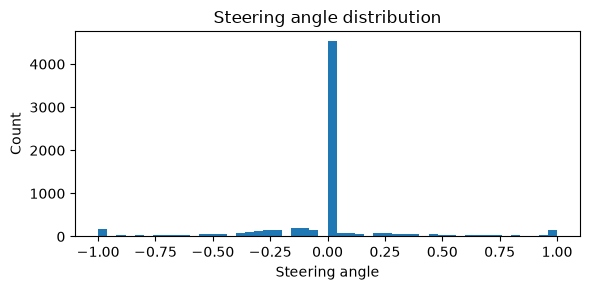

In [4]:
# steering is heavily concentrated near 0 (straight-line driving) -- this is the RAW, full
# dataset (before train/val split and before any rebalancing). See the "Train / validation split"
# section below for how this imbalance is addressed for training.
plt.figure(figsize=(6, 3))
plt.hist(df["steering"], bins=50)
plt.xlabel("Steering angle")
plt.ylabel("Count")
plt.title("Steering angle distribution")
plt.tight_layout()
plt.show()


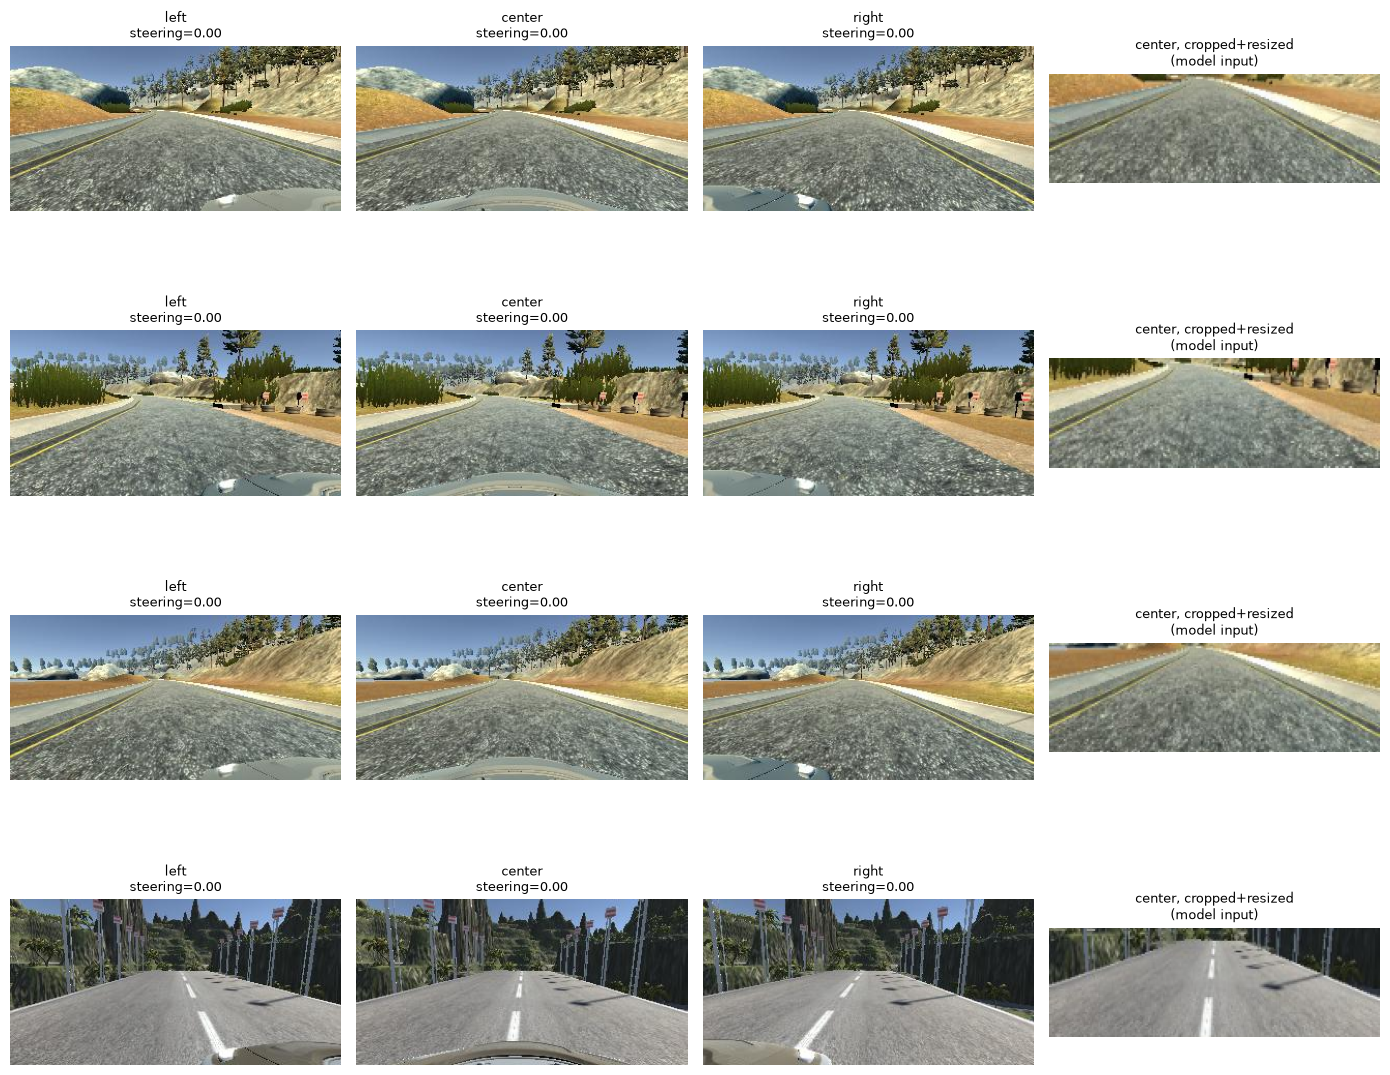

In [5]:
# sanity-check the pipeline visually -- confirms the crop keeps the road (not sky/hood), the
# resize doesn't distort proportions, and shows how different the left/right cameras look from
# center (which is why STEERING_CORRECTION is needed for them below)
sample_rows = df.sample(4, random_state=0)

fig, axes = plt.subplots(len(sample_rows), 4, figsize=(14, 3 * len(sample_rows)))
for row_idx, (_, row) in enumerate(sample_rows.iterrows()):
    center_image = None
    for col_idx, camera in enumerate(["left", "center", "right"]):
        image = cv2.cvtColor(cv2.imread(row[camera]), cv2.COLOR_BGR2RGB)  # cv2 loads BGR, matplotlib wants RGB
        if camera == "center":
            center_image = image
        axes[row_idx, col_idx].imshow(image)
        axes[row_idx, col_idx].set_title(f"{camera}\nsteering={row['steering']:.2f}", fontsize=9)
        axes[row_idx, col_idx].axis("off")

    # what the model actually sees after crop + resize (shown in RGB here for readability --
    # the real Dataset below also converts to YUV, which just looks like noise to the human eye)
    cropped = center_image[60:-25, :, :]
    resized = cv2.resize(cropped, (200, 66))
    axes[row_idx, 3].imshow(resized)
    axes[row_idx, 3].set_title("center, cropped+resized\n(model input)", fontsize=9)
    axes[row_idx, 3].axis("off")

plt.tight_layout()
plt.show()


## Dataset
Applies the standard PilotNet preprocessing (crop, resize, YUV, normalize) plus augmentation:
random left/right camera substitution with a steering correction, horizontal flip, random
translation, and brightness jitter. Left/right camera balance is handled explicitly in the
train/validation split below, not inside this class.

In [6]:
from functools import lru_cache

STEERING_CORRECTION = 0.2  # empirical value from the NVIDIA paper / Udacity nanodegree writeups

# horizontal translation augmentation: shifts the (cropped, pre-resize) image left/right and
# adjusts the steering target proportionally -- a continuous, finer-grained version of the
# discrete left/right-camera correction above
TRANSLATE_RANGE_PX = 25
STEERING_PER_PIXEL = 0.004


@lru_cache(maxsize=None)
def _read_image(image_path: str) -> np.ndarray:
    """Read and cache a training image so repeated epochs don't re-hit disk for the same file."""
    return cv2.imread(image_path)


class DrivingDataset(Dataset):
    """Loads a (center/left/right, steering) row and applies the PilotNet preprocessing pipeline.

    Training-only augmentation (camera choice, translation, brightness) is applied when
    `augment=True`; validation uses only the center camera with no augmentation. `flip_mode`, if
    present on `df`, makes left/right balance deterministic (see the split/loaders section below)
    instead of a per-call random coin flip.
    """

    def __init__(self, df: pd.DataFrame, augment: bool = True):
        self.df = df.reset_index(drop=True)
        self.augment = augment  # off for validation so val loss is stable/comparable across epochs

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.augment:
            camera = np.random.choice(["center", "left", "right"])
        else:
            camera = "center"  # validation always uses the true forward-facing view

        correction = {"center": 0.0, "left": STEERING_CORRECTION, "right": -STEERING_CORRECTION}[camera]
        steering = float(row["steering"]) + correction

        image = _read_image(row[camera])
        image = image[60:-25, :, :]  # crop sky (top) and hood (bottom) -- not useful for steering

        if self.augment:
            shift_x = np.random.uniform(-TRANSLATE_RANGE_PX, TRANSLATE_RANGE_PX)
            translation = np.float32([[1, 0, shift_x], [0, 1, 0]])
            image = cv2.warpAffine(
                image, translation, (image.shape[1], image.shape[0]), borderMode=cv2.BORDER_REPLICATE,
            )
            steering += shift_x * STEERING_PER_PIXEL

        image = cv2.resize(image, (200, 66))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2YUV)  # PilotNet is trained on YUV, not RGB

        # "never"/"always" give left/right balance a guaranteed, deterministic mirror pairing
        # (see the split/loaders section); rows without this column keep a random 50% flip.
        flip_mode = row["flip_mode"] if "flip_mode" in self.df.columns else "random"
        if self.augment and flip_mode == "always":
            do_flip = True
        elif self.augment and flip_mode == "random":
            do_flip = np.random.rand() < 0.5
        else:
            do_flip = False

        if do_flip:
            image = np.fliplr(image)
            steering = -steering  # mirrored road -> mirrored steering

        if self.augment:
            # brightness jitter directly on the Y (luma) channel -- already in YUV, so this is
            # just a scale-and-clip rather than a round-trip through another color space
            image = image.astype(np.float32)
            image[:, :, 0] = np.clip(image[:, :, 0] * np.random.uniform(0.6, 1.2), 0, 255)
        else:
            image = image.astype(np.float32)

        image = image / 127.5 - 1.0  # roughly [-1, 1]
        image = np.ascontiguousarray(image.transpose(2, 0, 1))  # HWC -> CHW for PyTorch

        return torch.from_numpy(image), torch.tensor([steering], dtype=torch.float32)


In [7]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# with both tracks combined (~7.3k rows total, ~5.9k in the train split), these caps use
# essentially all of the available data
N_TRAIN = 6000
N_VAL = 1200
train_df = train_df.sample(n=min(N_TRAIN, len(train_df)), random_state=42).reset_index(drop=True)
val_df = val_df.sample(n=min(N_VAL, len(val_df)), random_state=42).reset_index(drop=True)

# Straight-angle rows dominate raw counts (~60%, see the histogram above) and left turns
# outnumber right turns (~60:40) in the raw data. Both are corrected explicitly here, rather than
# leaving it to the DataLoader to reweight them:
#   - straight rows are physically downsampled to STRAIGHT_KEEP_FRAC of their count, so the model
#     isn't repeatedly shown a large pool of near-identical straight-road frames every epoch
#   - left-turn rows are kept 100% real; right-turn rows are padded with synthetic mirrored-left
#     images (flipped, steering negated) up to parity with the left-turn count -- this keeps
#     every left example genuinely real, rather than mirroring both directions into each other
STRAIGHT_THRESHOLD = 0.05
STRAIGHT_KEEP_FRAC = 0.6

turning_mask = train_df["steering"].abs() >= STRAIGHT_THRESHOLD
straight_rows = train_df[~turning_mask].sample(frac=STRAIGHT_KEEP_FRAC, random_state=42).copy()
straight_rows["flip_mode"] = "random"
print(f"Straight rows: {(~turning_mask).sum()} -> kept {len(straight_rows)} ({STRAIGHT_KEEP_FRAC:.0%})")

left_rows = train_df[train_df["steering"] <= -STRAIGHT_THRESHOLD].copy()
right_rows = train_df[train_df["steering"] >= STRAIGHT_THRESHOLD].copy()
left_rows["flip_mode"] = "never"
right_rows["flip_mode"] = "never"

deficit = len(left_rows) - len(right_rows)
print(f"Left (raw): {len(left_rows)}, Right (raw): {len(right_rows)}, deficit: {deficit}")

if deficit > 0:
    synthetic_right = left_rows.sample(n=deficit, random_state=42).copy()
    synthetic_right["flip_mode"] = "always"  # flipped left image + negated steering -> right
else:
    synthetic_right = left_rows.iloc[0:0].copy()  # no-op if right ever outnumbers left in a future split

train_df_expanded = pd.concat([straight_rows, left_rows, right_rows, synthetic_right], ignore_index=True)
print(f"train_df_expanded: {len(train_df_expanded)} rows ({len(synthetic_right)} synthetic right rows added)")

train_dataset = DrivingDataset(train_df_expanded, augment=True)
val_dataset = DrivingDataset(val_df, augment=False)

BATCH_SIZE = 64


def steering_class(angle: float) -> str:
    """Bucket a steering angle into left/straight/right, for reporting the train-set balance."""
    if angle <= -STRAIGHT_THRESHOLD:
        return "left"
    elif angle < STRAIGHT_THRESHOLD:
        return "straight"
    else:
        return "right"


# effective steering (after accounting for flip_mode) -- a synthetic "always"-flip row's stored
# steering is still its pre-flip (left) value, so this reports the TRUE resulting class mix
effective_steering = np.where(
    train_df_expanded["flip_mode"] == "always", -train_df_expanded["steering"], train_df_expanded["steering"],
)
train_classes = np.array([steering_class(a) for a in effective_steering])
class_counts = pd.Series(train_classes).value_counts()
print(f"Train class counts (effective, post-flip, post-reduction): {class_counts.to_dict()}")

# on Windows, Jupyter + multiprocessing DataLoader workers (spawn) can occasionally hang --
# keep NUM_WORKERS at 0 unless you've confirmed workers > 0 doesn't deadlock in your setup
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0,
)


Straight rows: 3609 -> kept 2165 (60%)
Left (raw): 1368, Right (raw): 890, deficit: 478
train_df_expanded: 4901 rows (478 synthetic right rows added)
Train class counts (effective, post-flip, post-reduction): {'straight': 2165, 'left': 1368, 'right': 1368}


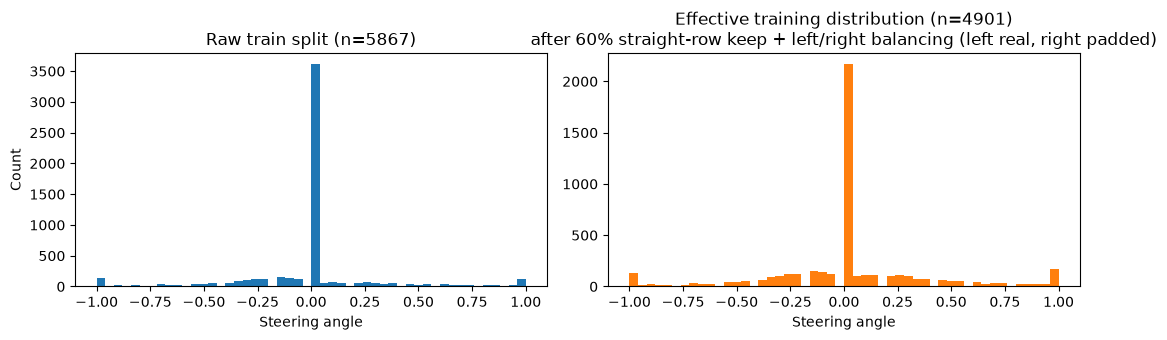

In [8]:
# visualize the effect of the straight-row reduction + left/right balancing: raw train split
# (left) vs. the actual effective steering distribution the model trains on (right) --
# "effective" means flip_mode="always" rows are shown at their real post-flip angle
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(train_df["steering"], bins=50, color="tab:blue")
axes[0].set_title(f"Raw train split (n={len(train_df)})")
axes[0].set_xlabel("Steering angle")
axes[0].set_ylabel("Count")

axes[1].hist(effective_steering.astype(float), bins=50, color="tab:orange")
axes[1].set_title(
    f"Effective training distribution (n={len(train_df_expanded)})\n"
    f"after {STRAIGHT_KEEP_FRAC:.0%} straight-row keep + left/right balancing (left real, right padded)"
)
axes[1].set_xlabel("Steering angle")

plt.tight_layout()
plt.show()


## Model — PilotNet

In [ ]:
class PilotNet(nn.Module):
    """NVIDIA's PilotNet: 5 conv layers + a 4-layer fully-connected regression head, predicting
    a single steering angle from a 66x200 YUV image (Bojarski et al., 2016)."""

    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=5, stride=2),  # 66x200 -> 31x98
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.Conv2d(24, 36, kernel_size=5, stride=2),  # 31x98 -> 14x47
            nn.BatchNorm2d(36),
            nn.ReLU(),
            nn.Conv2d(36, 48, kernel_size=5, stride=2),  # 14x47 -> 5x22
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.Conv2d(48, 64, kernel_size=3, stride=1),  # 5x22 -> 3x20
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),  # 3x20 -> 1x18
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),  # 64 * 1 * 18 = 1152 -- channels * height * width from the backbone above
            nn.Linear(1152, 126),
            nn.ReLU(),
            nn.Dropout(0.5),  # regularizes the fully-connected head against overfitting
            nn.Linear(126, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),  # single steering angle, no activation since this is regression
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.fc(x)
        return x


## Training

Epoch [1/18], Train Loss: 0.13268, Val Loss: 0.06853, LR: 1.0e-03
Epoch [2/18], Train Loss: 0.10019, Val Loss: 0.06774, LR: 1.0e-03
Epoch [3/18], Train Loss: 0.09372, Val Loss: 0.06600, LR: 1.0e-03
Epoch [4/18], Train Loss: 0.09558, Val Loss: 0.06215, LR: 1.0e-03
Epoch [5/18], Train Loss: 0.08871, Val Loss: 0.06663, LR: 1.0e-03
Epoch [6/18], Train Loss: 0.08305, Val Loss: 0.06218, LR: 5.0e-04
Epoch [7/18], Train Loss: 0.07988, Val Loss: 0.05989, LR: 5.0e-04
Epoch [8/18], Train Loss: 0.07674, Val Loss: 0.06088, LR: 5.0e-04
Epoch [9/18], Train Loss: 0.07489, Val Loss: 0.06087, LR: 2.5e-04
Epoch [10/18], Train Loss: 0.07129, Val Loss: 0.06037, LR: 2.5e-04
Early stopping...


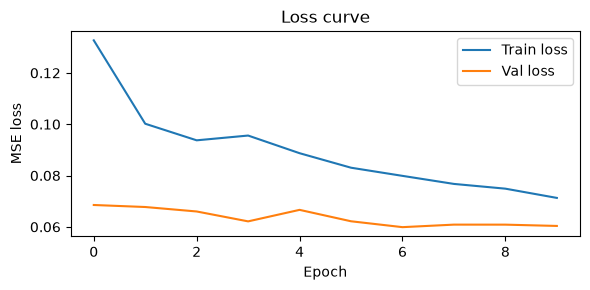

In [10]:
model = PilotNet()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
# shrinks the learning rate as soon as validation loss plateaus for 1 epoch -- with a rebalanced,
# augmented training signal that's noisier epoch-to-epoch, reacting sooner smooths that noise out
# faster than waiting longer would
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

n_epochs = 18
patience = 3  # early-stopping patience, higher than the scheduler's to ride out noisy epochs
best_val_loss = float("inf")
patience_left = patience
best_state = None
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, n_epochs + 1):
    model.train()
    train_loss = 0.0
    for images, steering in train_loader:
        optimizer.zero_grad()
        preds = model(images)
        loss_out = loss_fn(preds, steering)
        loss_out.backward()
        optimizer.step()
        train_loss += loss_out.item() * images.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, steering in val_loader:
            preds = model(images)
            loss_out = loss_fn(preds, steering)
            val_loss += loss_out.item() * images.size(0)
    val_loss /= len(val_loader.dataset)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    scheduler.step(val_loss)

    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch [{epoch}/{n_epochs}], Train Loss: {train_loss:.5f}, Val Loss: {val_loss:.5f}, LR: {lr:.1e}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        patience_left = patience
    else:
        patience_left -= 1
        if patience_left == 0:
            print("Early stopping...")
            break

if best_state is not None:
    model.load_state_dict(best_state)  # keep the best-val-loss weights, not just the last epoch's

# diverging lines (train falling, val flat/rising) mean overfitting -- converging lines mean
# there's still headroom to train longer or add data
plt.figure(figsize=(6, 3))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Loss curve")
plt.legend()
plt.tight_layout()
plt.show()


## Evaluation

In [11]:
SOFT_TURN_THRESHOLD = 0.05  # matches the straight/turning split used in the split/loaders section
HARD_TURN_THRESHOLD = 0.25  # roughly one full left/right-camera correction's worth of angle
LARGE_ERROR_THRESHOLD = 0.3


def _direction(angle: float) -> str:
    """3-way: is this frame straight, or does it call for a left/right correction at all?

    RMSE can't tell "wrong direction" apart from "right direction, different magnitude" -- this
    does.
    """
    if angle <= -SOFT_TURN_THRESHOLD:
        return "left"
    elif angle < SOFT_TURN_THRESHOLD:
        return "straight"
    else:
        return "right"


def _bucket(angle: float) -> str:
    """5-way direction + hard/soft severity bucket.

    Keeps the magnitude-severity information a pure direction check throws away: "direction
    correct but wildly wrong magnitude" is a real, dangerous failure that direction accuracy alone
    would score as correct.
    """
    if angle <= -HARD_TURN_THRESHOLD:
        return "hard-left"
    elif angle <= -SOFT_TURN_THRESHOLD:
        return "soft-left"
    elif angle < SOFT_TURN_THRESHOLD:
        return "straight"
    elif angle < HARD_TURN_THRESHOLD:
        return "soft-right"
    else:
        return "hard-right"


BUCKET_ORDER = ["hard-left", "soft-left", "straight", "soft-right", "hard-right"]


def report_direction_and_severity(actual: np.ndarray, predicted: np.ndarray, name: str) -> dict:
    """Print direction accuracy, large-error rate, and a 5-bucket confusion matrix.

    Complements (not replaces) the RMSE/MAE/R^2/straight-turning metrics above: those measure
    magnitude-sensitivity, this measures "was this a real driving mistake".
    """
    actual_dir = np.array([_direction(a) for a in actual])
    predicted_dir = np.array([_direction(p) for p in predicted])
    direction_accuracy = float((actual_dir == predicted_dir).mean())

    large_error_rate = float((np.abs(actual - predicted) > LARGE_ERROR_THRESHOLD).mean())

    actual_bucket = pd.Categorical([_bucket(a) for a in actual], categories=BUCKET_ORDER)
    predicted_bucket = pd.Categorical([_bucket(p) for p in predicted], categories=BUCKET_ORDER)
    confusion = pd.crosstab(
        pd.Series(actual_bucket, name="actual"), pd.Series(predicted_bucket, name="predicted"), dropna=False,
    )

    print(f"\n--- {name}: direction & severity ---")
    print(f"Direction accuracy (straight/left/right, threshold={SOFT_TURN_THRESHOLD}): {direction_accuracy * 100:.1f}%")
    print(f"Large-error rate (|actual - predicted| > {LARGE_ERROR_THRESHOLD}): {large_error_rate * 100:.1f}%")
    print(f"5-bucket confusion matrix (rows=actual, cols=predicted, hard cutoff={HARD_TURN_THRESHOLD}):")
    print(confusion)

    return {"direction_accuracy": direction_accuracy, "large_error_rate": large_error_rate, "confusion": confusion}

MSE:  0.05989
RMSE: 0.24473  (same units as steering angle, range is roughly [-1, 1])
MAE:  0.15987
R^2:  0.441  (1.0 = perfect, 0.0 = no better than always predicting the mean)
RMSE on straight frames (|angle| < 0.05, n=747): 0.11395
RMSE on turning frames  (|angle| >= 0.05, n=453): 0.37047

--- PilotNet: direction & severity ---
Direction accuracy (straight/left/right, threshold=0.05): 57.5%
Large-error rate (|actual - predicted| > 0.3): 15.5%
5-bucket confusion matrix (rows=actual, cols=predicted, hard cutoff=0.25):
predicted   hard-left  soft-left  straight  soft-right  hard-right
actual                                                            
hard-left          65         66        20           7           2
soft-left          10         59        35          11           0
straight           16        225       327         165          14
soft-right          0          3         4          27          10
hard-right          0          1         7          65          61


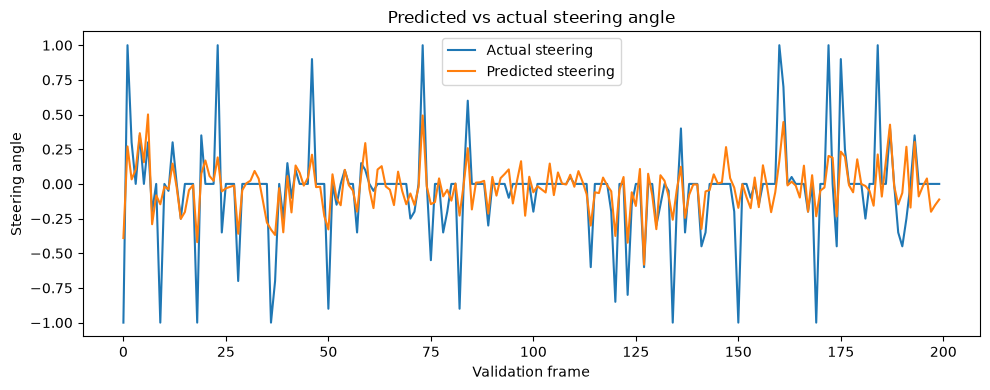

In [12]:
model.eval()

# evaluate on the full validation set (not just a slice) for statistically meaningful metrics
all_actual, all_predicted = [], []
with torch.no_grad():
    for images, steering in val_loader:
        preds = model(images)
        all_actual.extend(steering.squeeze(1).tolist())
        all_predicted.extend(preds.squeeze(1).tolist())

actual = np.array(all_actual)
predicted = np.array(all_predicted)
errors = actual - predicted

mse = float(np.mean(errors ** 2))
rmse = float(np.sqrt(mse))
mae = float(np.mean(np.abs(errors)))

# R^2 compares the model against a naive baseline that always predicts the mean steering angle --
# this matters because steering is heavily near-zero (see the histogram above), so a model that
# just learned to predict ~0 for everything can post a deceptively low MSE. R^2 near 0 means
# the model isn't beating that trivial baseline; close to 1 means it's actually tracking the signal
baseline_mse = float(np.mean((actual - actual.mean()) ** 2))
r2 = 1 - mse / baseline_mse

# straight frames dominate the dataset and are easy (predicting ~0 is nearly correct), so they can
# hide poor performance on turns in an aggregate average -- report turning error separately since
# that's the part that actually matters for staying on the road
turning = np.abs(actual) >= 0.05
straight_rmse = float(np.sqrt(np.mean(errors[~turning] ** 2))) if (~turning).any() else float("nan")
turning_rmse = float(np.sqrt(np.mean(errors[turning] ** 2))) if turning.any() else float("nan")

print(f"MSE:  {mse:.5f}")
print(f"RMSE: {rmse:.5f}  (same units as steering angle, range is roughly [-1, 1])")
print(f"MAE:  {mae:.5f}")
print(f"R^2:  {r2:.3f}  (1.0 = perfect, 0.0 = no better than always predicting the mean)")
print(f"RMSE on straight frames (|angle| < 0.05, n={(~turning).sum()}): {straight_rmse:.5f}")
print(f"RMSE on turning frames  (|angle| >= 0.05, n={turning.sum()}): {turning_rmse:.5f}")

# a simpler baseline configuration (no rebalancing, no scheduler, no translation/brightness
# augmentation) is compared against these results in report/behavioral_cloning_report.pdf
report_direction_and_severity(actual, predicted, "PilotNet")

# qualitative check on the first 200 frames -- does the predicted line track the actual line's
# turns, or does it stay flat near zero regardless of what the road is doing?
n_frames = min(200, len(actual))
plt.figure(figsize=(10, 4))
plt.plot(actual[:n_frames], label="Actual steering")
plt.plot(predicted[:n_frames], label="Predicted steering")
plt.xlabel("Validation frame")
plt.ylabel("Steering angle")
plt.title("Predicted vs actual steering angle")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

model_path = models_dir / "pilotnet_behavioral_cloning.pt"
torch.save(model.state_dict(), model_path)
print(f"Saved model to {model_path}")


Saved model to models\pilotnet_behavioral_cloning.pt


## Simulator
Downloads the official Udacity self-driving-car-sim (Term 1) and runs the trained model inside it
in Autonomous Mode. Works on Windows, macOS, and Linux -- the correct per-OS build is downloaded
automatically. This can't run as a single top-to-bottom cell end-to-end: the simulator is a
separate GUI application, so the flow is: download + extract here, launch the simulator, then run
the "Run the trained model live" cell below, which starts the driving server the simulator
connects to.

In [ ]:
import platform
import stat
import urllib.request
import zipfile

# Term 1 v2 build -- this is the simulator whose "Training Mode" recordings match our CSV/IMG
# format (center/left/right cameras + steering angle), unlike the Term 2/3 builds. Udacity hosts
# separate builds per OS at the same path; this picks the one matching the machine the notebook
# is actually running on.
SIMULATOR_BASE_URL = "https://s3-us-west-1.amazonaws.com/udacity-selfdrivingcar/Term1-Sim"
SYSTEM = platform.system()  # "Windows", "Darwin" (macOS), or "Linux"
SIMULATOR_ASSET = {"Windows": "windows", "Darwin": "mac", "Linux": "linux"}[SYSTEM]
SIMULATOR_URL = f"{SIMULATOR_BASE_URL}/term1-simulator-{SIMULATOR_ASSET}.zip"

simulator_dir = Path("simulator")
zip_path = Path(f"term1-simulator-{SIMULATOR_ASSET}.zip")

if not simulator_dir.exists():
    print(f"Downloading {SYSTEM} simulator build (~100+ MB)...")
    urllib.request.urlretrieve(SIMULATOR_URL, zip_path)
    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(simulator_dir)
    zip_path.unlink()
else:
    print("Simulator already downloaded.")


def _make_executable(path: Path) -> None:
    path.chmod(path.stat().st_mode | stat.S_IEXEC | stat.S_IXGRP | stat.S_IXOTH)


def find_launch_target(root: Path):
    """Find the thing to actually launch, which differs by OS: a .exe on Windows, a .app bundle
    on macOS (launched via `open`, not executed directly), or a bare executable file on Linux.
    The mac and linux zips don't preserve the Unix executable bit on extraction, so it's set
    explicitly here rather than assumed. Returns None if nothing was found."""
    if SYSTEM == "Windows":
        matches = list(root.rglob("*.exe"))
    elif SYSTEM == "Darwin":
        matches = list(root.rglob("*.app"))
        for app in matches:
            for binary in (app / "Contents" / "MacOS").glob("*"):
                if binary.is_file():
                    _make_executable(binary)
    else:
        matches = [p for p in root.rglob("beta_simulator.x86_64") if p.is_file()]
        if not matches:
            matches = [p for p in root.rglob("beta_simulator.x86") if p.is_file()]
        for p in matches:
            _make_executable(p)
    return matches[0] if matches else None


launch_target = find_launch_target(simulator_dir)
print(f"Simulator ready at: {simulator_dir.resolve()}")
print(f"Launch target: {launch_target}")


In [ ]:
import subprocess

# opens the simulator GUI window without blocking this notebook -- the OS may show a firewall
# prompt the first time the live-driving cell below listens on port 4567; allow it (local network
# only). macOS .app bundles are launched via `open` (the standard way -- executing the binary
# inside Contents/MacOS/ directly skips normal app-bundle initialization); Windows/Linux
# executables are run directly.
if launch_target:
    if SYSTEM == "Darwin":
        subprocess.Popen(["open", str(launch_target)])
    else:
        subprocess.Popen([str(launch_target)], cwd=str(launch_target.parent))
    print(f"Launching {launch_target} -- pick a track, then click Autonomous Mode")
else:
    print("No simulator executable found -- check the extraction above")


### Run the trained model live
With the simulator open and a track selected, click **Autonomous Mode** (not Training Mode), then
run the cell below. It starts a small local server that the simulator connects to automatically
on port 4567, receives each camera frame, and sends back a predicted steering angle + throttle.

The cell blocks and streams `steering=... throttle=... speed=...` output while connected; **use
the Interrupt/Stop button to end the session** once you're done (or after closing the simulator
window).

Note: if the car drives noticeably worse than the offline validation metrics suggested, that's
expected -- those metrics are open-loop (one frame at a time against a fixed dataset), while
driving is closed-loop (small errors compound over time as the car drifts into positions its
training data rarely covered).

In [16]:
%pip install -q python-engineio uvicorn pillow

import base64
import json
from io import BytesIO

import engineio
import uvicorn
from PIL import Image

TARGET_SPEED = 15.0  # mph -- kept modest; the model was trained on human driving around this range


def preprocess_live(image_rgb: np.ndarray) -> torch.Tensor:
    """Mirror DrivingDataset's preprocessing for a live simulator frame (no augmentation).

    Simulator frames arrive as RGB via PIL, unlike training's cv2.imread (BGR).
    """
    image = image_rgb[60:-25, :, :]
    image = cv2.resize(image, (200, 66))
    image = cv2.cvtColor(image, cv2.COLOR_RGB2YUV)
    image = image.astype(np.float32) / 127.5 - 1.0
    image = np.ascontiguousarray(image.transpose(2, 0, 1))
    return torch.from_numpy(image).unsqueeze(0)


eio_server = engineio.AsyncServer(async_mode="asgi", cors_allowed_origins="*")
# the simulator's client requests /socket.io/ (Socket.IO's conventional path), but
# engineio.ASGIApp defaults to /engine.io/ -- override it to match what's actually sent
asgi_app = engineio.ASGIApp(eio_server, engineio_path="socket.io")

model.eval()  # the trained model from the Training section above, used directly, in-memory


@eio_server.on("connect")
async def on_connect(sid, environ):
    print("Simulator connected:", sid)


@eio_server.on("message")
async def on_message(sid, data):
    """Handle one telemetry frame: predict steering, compute throttle, send the response back.

    Socket.IO frames its own packet type onto the Engine.IO MESSAGE payload ('2' = EVENT followed
    by a JSON [event_name, event_data] array); this simulator client sends that directly without
    the official Socket.IO CONNECT handshake, so we talk to the low-level `engineio` package and
    hand-roll this framing rather than using `socketio.Server`, which would silently drop it.
    """
    if not isinstance(data, str) or not data.startswith("2["):
        return

    event_name, payload = json.loads(data[1:])
    if event_name != "telemetry" or payload is None:
        return

    speed = float(payload["speed"])
    image = np.asarray(Image.open(BytesIO(base64.b64decode(payload["image"]))))

    with torch.no_grad():
        steering_angle = float(model(preprocess_live(image)).item())

    # simple proportional throttle: back off as speed approaches the target, floor at 0.1 so it
    # doesn't stall on hills -- not a real PID controller, just enough to keep moving
    throttle = max(0.1, 1.0 - speed / TARGET_SPEED)

    print(f"steering={steering_angle:+.3f}  throttle={throttle:.3f}  speed={speed:.1f}")
    response = json.dumps(["steer", {"steering_angle": str(steering_angle), "throttle": str(throttle)}])
    await eio_server.send(sid, "2" + response)


print("Listening on port 4567 -- pick a track in the simulator, then click Autonomous Mode")
print("Use the Interrupt/Stop button to end this cell once you're done driving.")

# A Jupyter cell already runs inside the kernel's own asyncio event loop, so we await the server
# directly on that loop (via Jupyter's native top-level `await`) instead of calling uvicorn.run(),
# which tries to start a second, competing event loop and fails with "asyncio.run() cannot be
# called from a running event loop".
live_server = uvicorn.Server(uvicorn.Config(asgi_app, host="0.0.0.0", port=4567, log_level="warning"))
await live_server.serve()



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Listening on port 4567 -- pick a track in the simulator, then click Autonomous Mode
Use the Interrupt/Stop button to end this cell once you're done driving.
Simulator connected: R-O_zvEdvxwegTvRAAAA
steering=-0.085  throttle=0.883  speed=1.8
steering=-0.085  throttle=0.883  speed=1.8
steering=-0.117  throttle=0.650  speed=5.3
steering=-0.117  throttle=0.650  speed=5.3
steering=-0.124  throttle=0.786  speed=3.2
steering=-0.114  throttle=0.914  speed=1.3
steering=-0.117  throttle=0.879  speed=1.8
steering=-0.118  throttle=0.902  speed=1.5
steering=-0.123  throttle=0.931  speed=1.0
steering=-0.130  throttle=0.919  speed=1.2
steering=-0.122  throttle=0.901  speed=1.5
steering=-0.125  throttle=0.888  speed=1.7
steering=-0.130  throttle=0.871  speed=1.9
steering=-0.120  throttle=0.853  speed=2.2
steering=-0.113  throttle=0.823  speed=2.7
steering=-0.118  throttle=0.798  speed=3.0
steering=-0.122  throttle=0.765  speed=3.5
stee